# Environment
> Air humidity and soil moisture over the batch, and how soil drying shows in leaf temperature

The Ruuvi sensor on `SP_01` logs air temperature and relative humidity for the whole greenhouse. Each node logs the moisture and temperature of its own pot. This notebook plots both over the batch from 23 September to 5 October 2026.

In [ ]:
import pandas as pd, matplotlib.pyplot as plt
from fastcore.utils import *
from speaking_plants.clean import *
from speaking_plants.leaf import *

In [ ]:
#| eval: false
data = Path('../data')
mdf = share_ruuvi(measurements(clean(read_logs(sorted(data.glob('dados_*.csv'))))))
air = mdf[mdf.node_id == 'SP_01'].set_index('time')

## Air humidity

Relative humidity and air temperature from the Ruuvi sensor. Gaps are outages of `SP_01` or missing Ruuvi readings. The dashed line marks 30 September, when the scenes of all four cameras changed:

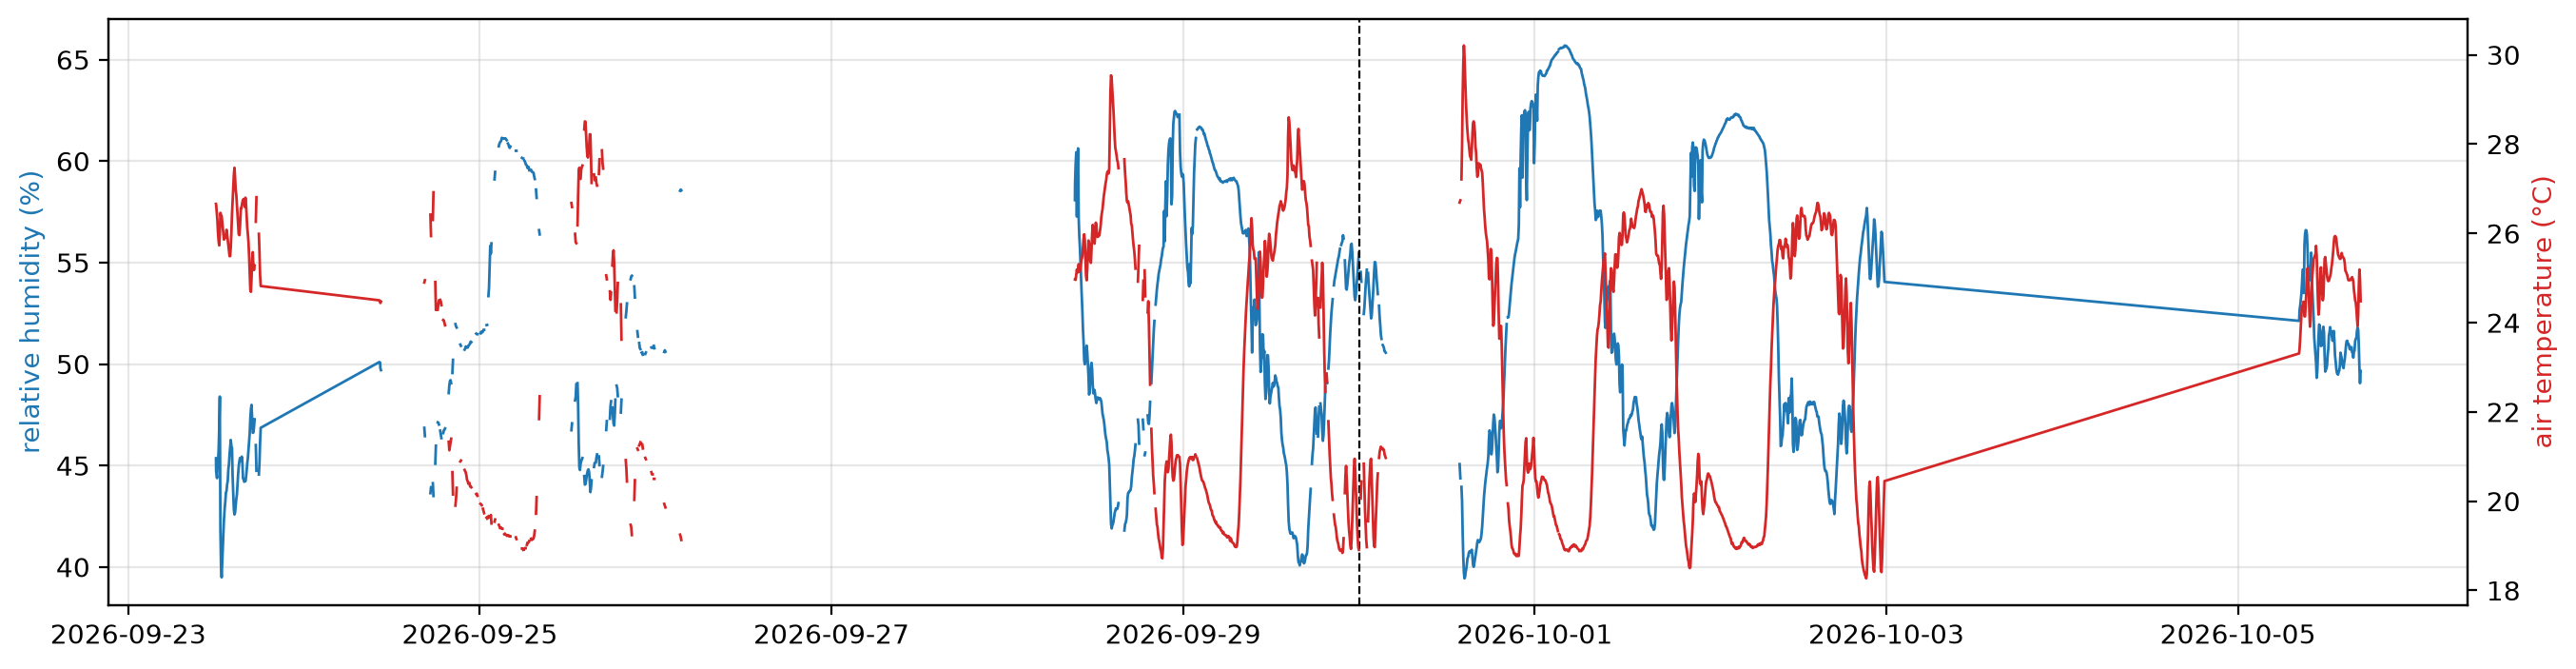

In [ ]:
#| eval: false
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(air.index, air.ruuvi_humidity, lw=1, c='C0')
ax.set_ylabel('relative humidity (%)', color='C0')
ax2 = ax.twinx()
ax2.plot(air.index, air.ruuvi_temp, lw=1, c='C3')
ax2.set_ylabel('air temperature (°C)', color='C3')
ax.axvline(pd.Timestamp('2026-09-30'), c='k', ls='--', lw=0.8); ax.grid(alpha=0.3)

By time of day, one line per day:

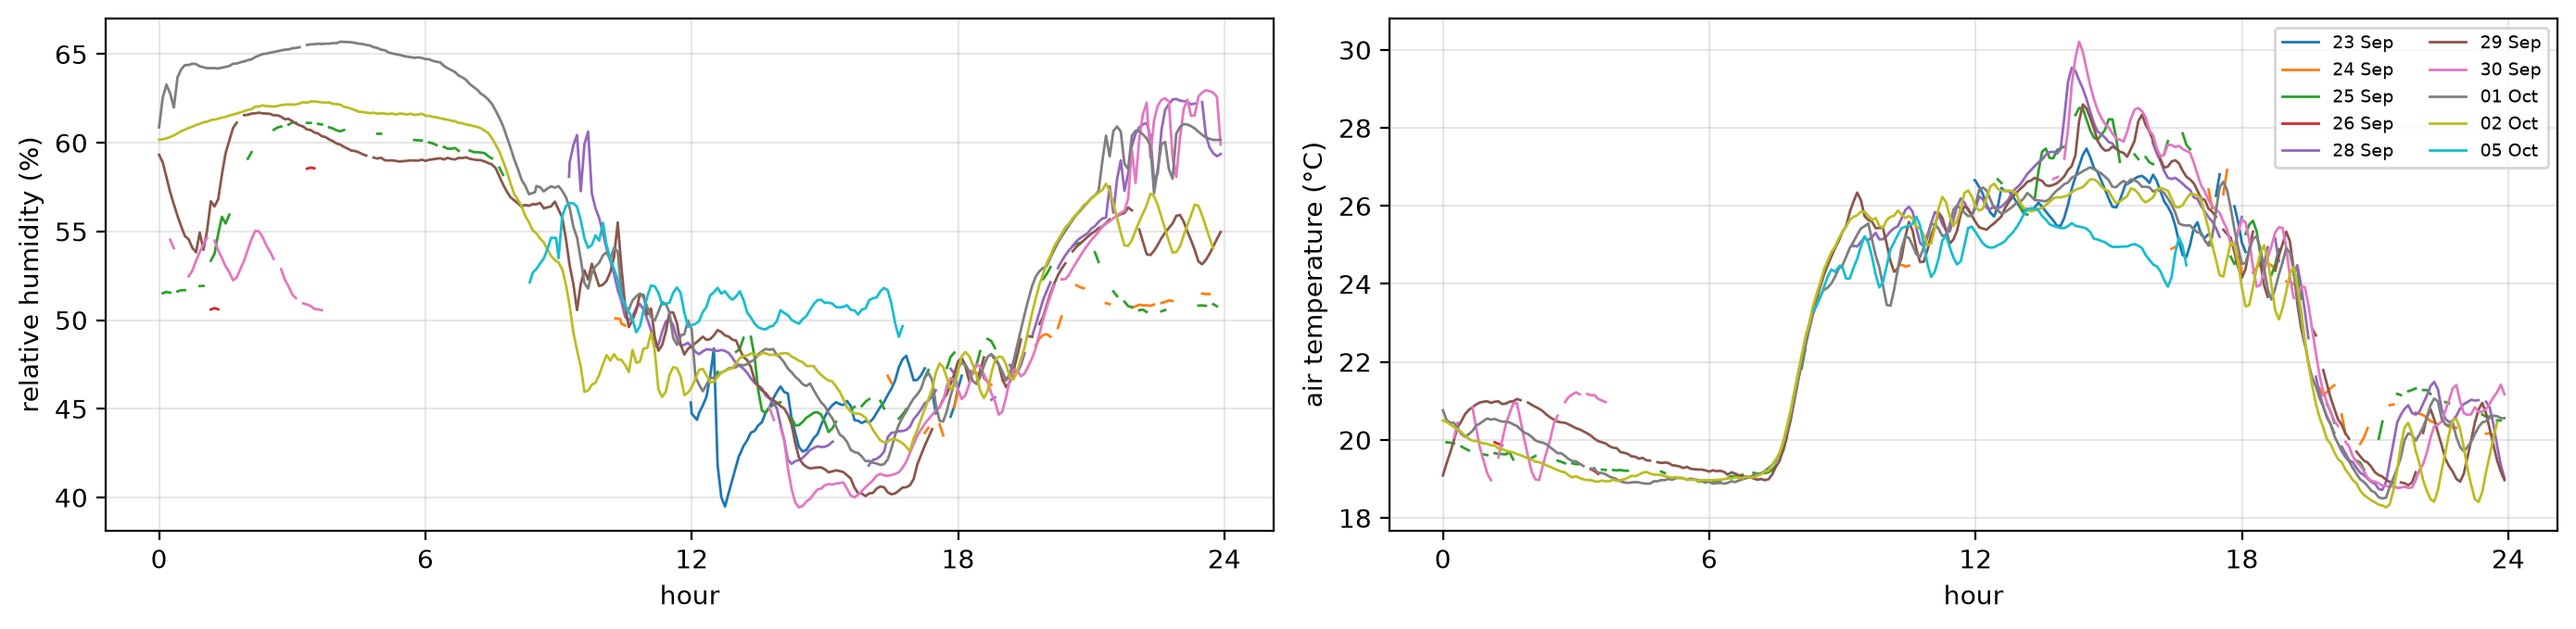

In [ ]:
#| eval: false
a = air.reset_index().assign(day=lambda d: d.time.dt.normalize(), hour=lambda d: (d.time - d.time.dt.normalize()).dt.total_seconds() / 3600)
fig, axs = plt.subplots(1, 2, figsize=(14, 3.5))
for ax, col, lab in zip(axs, ['ruuvi_humidity', 'ruuvi_temp'], ['relative humidity (%)', 'air temperature (°C)']):
    for d, g in a.groupby('day'): ax.plot(g.hour, g[col], lw=1, label=f'{d:%d %b}')
    ax.set_xticks(range(0, 25, 6)); ax.set_xlabel('hour'); ax.set_ylabel(lab); ax.grid(alpha=0.3)
axs[1].legend(fontsize=7, ncol=2)
plt.tight_layout()

## Soil moisture

Soil moisture and soil temperature of each node. The soil sensors of `SP_02` and `SP_03` failed for most of the batch, so their lines are short:

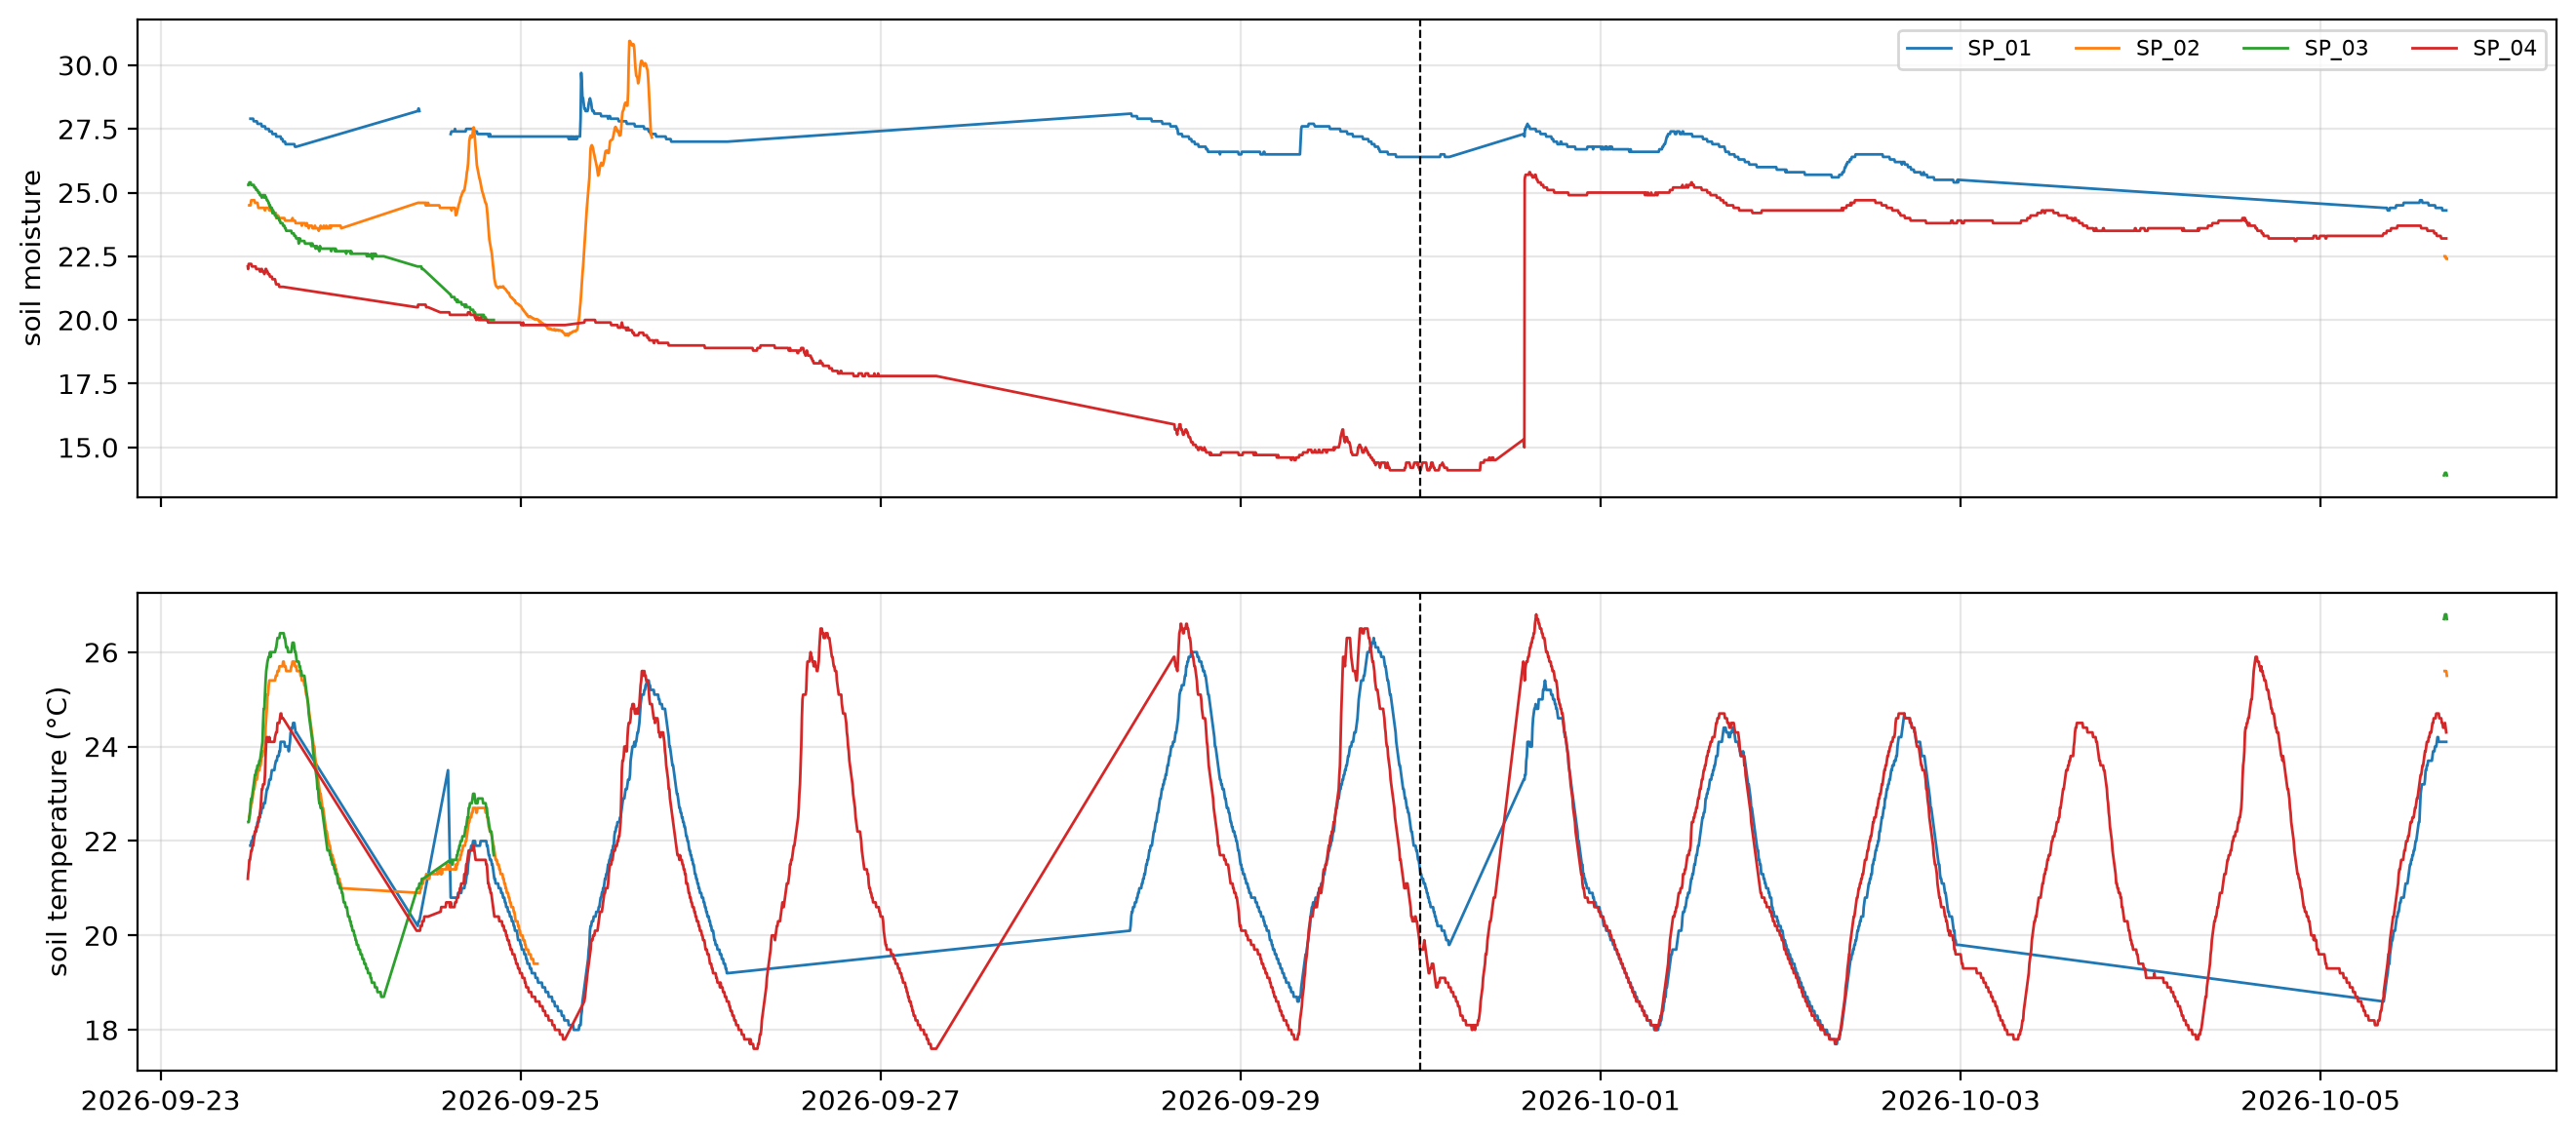

<matplotlib.legend.Legend>

In [ ]:
#| eval: false
fig, axs = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
for node, g in mdf.groupby('node_id'):
    axs[0].plot(g.time, g.soil_moisture, lw=1, label=node)
    axs[1].plot(g.time, g.soil_temperature, lw=1, label=node)
axs[0].set_ylabel('soil moisture'); axs[1].set_ylabel('soil temperature (°C)')
for ax in axs: ax.axvline(pd.Timestamp('2026-09-30'), c='k', ls='--', lw=0.8); ax.grid(alpha=0.3)
axs[0].legend(fontsize=8, ncol=4)

The daily median shows the trends without the daily cycle:

In [ ]:
#| eval: false
mdf.groupby([mdf.time.dt.normalize().rename('day'), 'node_id']).soil_moisture.median().unstack().round(1)

node_id,SP_01,SP_02,SP_03,SP_04
day,,,,
2026-09-23,27.3,23.9,23.4,21.9
2026-09-24,27.3,24.4,22.1,20.2
2026-09-25,27.2,24.1,NaN,19.8
2026-09-26,27.0,NaN,NaN,18.8
2026-09-27,NaN,NaN,NaN,17.8
2026-09-28,27.2,NaN,NaN,14.8
2026-09-29,26.6,NaN,NaN,14.7
2026-09-30,26.8,NaN,NaN,20.1
2026-10-01,26.7,NaN,NaN,25.0


The soil of `SP_04` dried from 21.9 on 23 September to 14.7 on 29 September. Its moisture rose from 15.3 to 25.8 between 13:41 and 14:35 on 30 September, which looks like watering. `SP_01` dried slowly, from 27.3 to 24.5, and shows no watering.

## Soil drying and leaf temperature on SP_04

If the plant on `SP_04` was short of water on 29 September, it would transpire less and its leaves would warm above air temperature at midday. The table gives, per day, the mean unmasked leaf minus air temperature from 11:00 to 14:00, with the number of 5-minute values that have an air reading, next to the median soil moisture:

In [ ]:
#| eval: false
us = leaf_series(mdf, no_masks(full_days(mdf, min_n=13)))
s4 = us[(us.node_id == 'SP_04') & (us.hour >= 11) & (us.hour < 14)]
mid = s4.groupby('day').agg(dt_leaf_air=('dt_leaf_air', 'mean'), n_air=('dt_leaf_air', 'count'))
soil = mdf[mdf.node_id == 'SP_04'].groupby(mdf.time.dt.normalize().rename('day')).soil_moisture.median()
mid.join(soil).round(2)

,dt_leaf_air,n_air,soil_moisture
day,,,
2026-09-23,-0.78,24,21.90
2026-09-24,NaN,0,20.20
2026-09-25,-1.32,16,19.75
2026-09-26,NaN,0,18.80
2026-09-29,0.75,36,14.70
2026-09-30,3.27,1,20.10
2026-10-01,-1.20,36,25.00
2026-10-02,-1.33,36,24.30
2026-10-03,NaN,0,23.80


The midday difference is negative while the soil is moist and positive on 29 September, the driest day with air readings. The camera scene of `SP_04` changed on 30 September as well, and only three days before the watering have midday air readings: 23, 25 and 29 September. This is a lead to test on the next batch, not a result.